In [1]:
import xarray as xr
import os   
import parflow as pf
import plotly.express as px
from parflow.tools.hydrology import calculate_overland_flow_grid, calculate_subsurface_storage, calculate_water_table_depth
import numpy as np
import shutil
import json
import plotly.io as pio

In [2]:
# import config from paper_figures/ (parent of this notebook's folder)
import sys
from pathlib import Path

try:
    _paper_figures = Path(__file__).resolve().parent.parent
except NameError:
    # Jupyter: __file__ is undefined; cwd is usually paper_figures or pumping/
    _cwd = Path.cwd()
    _paper_figures = _cwd.parent if _cwd.name == "pumping" else _cwd

sys.path.insert(0, str(_paper_figures))
import utils

In [3]:
ensemble_name = "pumping_ensemble"
ensemble_member = "baseline"
# baseline = utils.read_simulation_data(ensemble_name, ensemble_member, utils.DOMAIN)
# ensemble_member = "pumping_0_00001"
data = utils.read_simulation_data(ensemble_name, ensemble_member, utils.DOMAIN)
data.info()

/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/bwest/conda-envs/droughts/share/proj failed
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 

xarray.Dataset {
dimensions:
	time = 219000 ;
	z = 10 ;
	y = 136 ;
	x = 70 ;

variables:
	float64 pressure(time, z, y, x) ;
	float64 saturation(time, z, y, x) ;
	float64 evaptrans(time, z, y, x) ;
	float64 overland_bc_flux(time, y, x) ;
	float64 mask(time, z, y, x) ;
	float64 mannings(time, y, x) ;
	float64 porosity(time, z, y, x) ;
	float64 specific_storage(time, z, y, x) ;
	float64 DZ_Multiplier(time, z, y, x) ;
	float64 slopex(time, y, x) ;
	float64 slopey(time, y, x) ;
	float64 perm_x(time, z, y, x) ;
	float64 perm_y(time, z, y, x) ;
	float64 perm_z(time, z, y, x) ;
	float64 overland_flow(time, y, x) ;
	float64 storage(time, z, y, x) ;
	float64 time(time) ;

// global attributes:
}

In [4]:
# Run the cell above first so `data` exists.
#
# parflow.tools.hydrology.calculate_water_table_depth(pressure, saturation, dz):
#   - pressure, saturation: ndarray (nz, ny, nx), bottom layer → top (matches xarray z, y, x)
#   - dz: ndarray shape (nz,) only — layer thicknesses, not a full 3D field
def get_wtd(data, time_index=0):
    pressure_snapshot = data.pressure.isel(time=time_index).values
    saturation_snapshot = data.saturation.isel(time=time_index).values
    dz_xr = data.DZ_Multiplier.isel(time=time_index)

    if dz_xr.ndim == 1:
        dz_1d = np.asarray(dz_xr.values, dtype=float)
    else:
        # (z, y, x) in processed runs: use one column (typical when dz does not vary horizontally)
        dz_1d = np.asarray(dz_xr.isel(x=20, y=20).values, dtype=float)
        dz_1d = dz_1d*200.

    print("pressure:", pressure_snapshot.shape, "saturation:", saturation_snapshot.shape, "dz:", dz_1d.shape)

    wtd = calculate_water_table_depth(pressure_snapshot, saturation_snapshot, dz_1d)
    print("water table depth (ny, nx):", wtd.shape)
    # apply the mask to the wtd
    mask = data.mask.isel(time=0, z=0).values
    #normalize the mask to 0-1
    mask = mask/mask.max()
    wtd = wtd*mask

    return wtd


In [ ]:
wtd1 = get_wtd(data, time_index=0)
wtd2 = get_wtd(data, time_index=8760*20)
px.imshow(wtd2-wtd1)

pressure: (10, 136, 70) saturation: (10, 136, 70) dz: (10,)
water table depth (ny, nx): (136, 70)


In [6]:
px.imshow(wtd)

In [7]:
# print((dz_xr*200.).isel(x=20, y=20).values)

In [8]:
mask = data.mask.isel(time=0, z=0).values
mask = mask/mask.max()
# get the average wtd but only where the mask is 1
# mask and wtd are both numpy arrays here (not xarray DataArrays), so use np.where and np.mean
import numpy as np

def get_wtd_avg(wtd, mask):
    wtd_masked = np.where(mask == 1, wtd, np.nan)
    wtd_avg = np.nanmean(wtd_masked)
    return wtd_avg

wtd_avg = get_wtd_avg(wtd, mask)
print("Average WTD (masked):", wtd_avg)


Average WTD (masked): 74.438709649414


In [9]:
wtds = []
for year in range(0,20):
    year_length = 8760
    wtd = get_wtd(data, year*year_length)
    wtd_avg = get_wtd_avg(wtd, mask)
    print("Average WTD (masked) for year", year, ":", wtd_avg)
    wtds.append(wtd_avg)

wtds = np.array(wtds)
print(wtds.shape)




pressure: (10, 136, 70) saturation: (10, 136, 70) dz: (10,)
water table depth (ny, nx): (136, 70)
Average WTD (masked) for year 0 : 74.438709649414
pressure: (10, 136, 70) saturation: (10, 136, 70) dz: (10,)
water table depth (ny, nx): (136, 70)
Average WTD (masked) for year 1 : 76.21126524825755
pressure: (10, 136, 70) saturation: (10, 136, 70) dz: (10,)
water table depth (ny, nx): (136, 70)
Average WTD (masked) for year 2 : 77.40667046588413
pressure: (10, 136, 70) saturation: (10, 136, 70) dz: (10,)
water table depth (ny, nx): (136, 70)
Average WTD (masked) for year 3 : 78.40523147923201
pressure: (10, 136, 70) saturation: (10, 136, 70) dz: (10,)
water table depth (ny, nx): (136, 70)
Average WTD (masked) for year 4 : 79.19941943017837
pressure: (10, 136, 70) saturation: (10, 136, 70) dz: (10,)
water table depth (ny, nx): (136, 70)
Average WTD (masked) for year 5 : 79.81564521709404
pressure: (10, 136, 70) saturation: (10, 136, 70) dz: (10,)
water table depth (ny, nx): (136, 70)
Aver

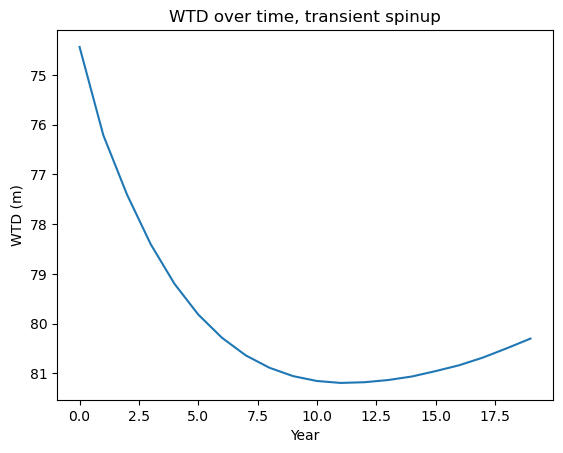

In [11]:
import matplotlib.pyplot as plt
#plot the wtds with appropriate labels and title
plt.plot(wtds)
plt.xlabel("Year")
plt.ylabel("WTD (m)")
plt.title("WTD over time, transient spinup")
#invert the y axis
plt.gca().invert_yaxis()
plt.show()